In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Cover Letter
The data from IB's FTP can be interpreted generally as information on the difficulty of borrowing securities.
It answers the questions: 1) Am I able to borrow? 2) Whats the expected borrow cost? (expected since fee/rebate can change
during lending duration). So largely these affect whether a short is feasible, how expensive it is to maintain, and how position sizing / risk limits should adjust as borrow becomes scarce.
In a systematic setting, this feed can be valuable as a constraint (borrow friction/crowding proxy), although not necessarily as
a clean, continuously updating market signal (as we will see).
In the bigger picture, this might be combined with market data (for a more direct link to future returns) or other borrow feeds (for validation). This data can also inform whether or not a given signal should be executed, as it effectively summarises supply constraints and borrowing costs.

In this project, an ETL pipeline is used to download from the FTP and create a dataset. This is then explored in the 
exploratory data analysis section, which is then used to inform some proposals for an ML model.

Quick note on (relevant) IB variables:
- Rebate rate: precentage rate paid to lenders for lending their shares
- Fee rate: percentage rate paid by borrowers to be able to short
- Available shares: number of available shares for borrowing, with >1E6 indicating 'unlimited' supply

The pipeline works roughly as follows:
- Monitor ftp for updates (using changes to MD5 hash, and ensuring that every update is captured)
- Download updated files and transform
- Download corresponding market variables (close price etc.) from yahoo finance
- Load both sources of data into an 'enriched' dataset

The exploratory data analysis starts with getting a basic understanding typical updates, before clustering in terms of
IB variables. This allows for a better understanding later on of the varied behaviour exhibited by these securities.
A few statistical analyses are then performed, with the aim of informing future feature proposals.

Finally, features involving these IB variables are suggested in order to aid in the prediction of pricing dynamics, although
its important to note that these are not intended to directly predict future returns on their own due to their nature.

The largest limitation was the small sample size, due to both the relatively small number of tickers in the enriched dataset, and the small total collection time relative to the update cadence (particularly given that actual updates to fee/availability values were rare). This left a few insights on the table, so re-running the analysis on a larger sample would be the first step for further study. 
Another quirk was the infrequent changes in key IB variables relative to the almost arbitrarily frequent pricing updates. To get around this, a few analyses were performed in event-time rather than real-time. However there was no way to get around the small number of actual IB variable changes per ticker over the whole dataset, so the degree of accuracy to which insights were made was sub-optimal.

## Delivery Mechanics and Datasets
- Updates to the FTP occur every 15 minutes, on weekends and weekdays, although there are occassional updates which fall outside of this schedule (~1/100)
- Data is split into files for 18 seperate regions as well as their MD5 hashes
- Largest file is the USA data file which is 1.6mb
- Occassional FTP error 113's, can get around with a near-immediate reconnect
- Occassional file deletion, occurs simultaneously with file updates


All following analysis will be performed on data collected from 2025-11-04 18:54:41 to 2025-11-09 00:31:44, ~100h.

Variables of interest originate from either IB's public FTP (IB), or the Yahoo Finance API (YF). They are as follows:  
Fee rate (IB)  
Rebate rate (IB)  
Available Shares (IB)  
Close Price (YF)  
Volume (YF)  
Market Cap (YF)  
Sector (YF)  

The basic dataset contains only IB variables.  
The enriched dataset contains both IB and YF variables for a set of 50 US securities.  

IB variables were collected continuously throughout the period every 15 minutes. For the enriched dataset, YF variables were collected every 5 minutes during market hours only, matching these to the most recent IB timestamp, resulting in datapoints separated by 15 minutes. The close price was also forward-filled to non-market hours for completeness.

In [2]:
# Load enriched dataset
directory = Path("example_datasets/enriched")
dfs = [] 
for date_dir in sorted(directory.glob('dt=*')):
    for fp in date_dir.glob('*.parquet'):
        dfs.append(pd.read_parquet(fp))

df = pd.concat(dfs, ignore_index=True)
df['asof_utc'] = pd.to_datetime(df['asof_utc'])
df = df.sort_values(['ticker', 'asof_utc'])
df = df[df['day_of_week'] < 5] #weekdays
df = df[df['is_market_hours'] == True] #filter to market hours
print(df.head(n=2))

  ticker            asof_utc region  fee_raw  rebate_raw  spread_raw  fee_bps  \
0    ABR 2025-11-04 18:54:42    usa   1.8324      2.0376     -0.2052   183.24   
1    ABR 2025-11-04 19:10:14    usa   1.8324      2.0376     -0.2052   183.24   

   rebate_bps  spread_bps  available_shares  ...    open   high   low  close  \
0      203.76      -20.52            250000  ...  9.6100  9.655  9.61  9.635   
1      203.76      -20.52            250000  ...  9.6199  9.630  9.60  9.600   

   volume       sector         industry  market_cap  exchange  currency  
0   90477  Real Estate  REIT - Mortgage  1805255168       NYQ       USD  
1   32846  Real Estate  REIT - Mortgage  1805255168       NYQ       USD  

[2 rows x 29 columns]


## Exploratory Data Analysis
Here we examine how the IB variables of interest (fee rate, rebate rate, available shares) behave within our dataset. Note that here I use datasets from /example_datasets, but after running the ETL pipeline the datasets will appear in /data.

### Update Frequency
Firstly, while noting the theoretical max update frequency of 15 minutes, how often do these variables actually tend to update?

Median update frequencies:
fee_raw             669.662500
rebate_raw          669.662500
spread_raw          669.662500
available_shares    553.666667
close                15.562631
volume               15.561789
dtype: float64


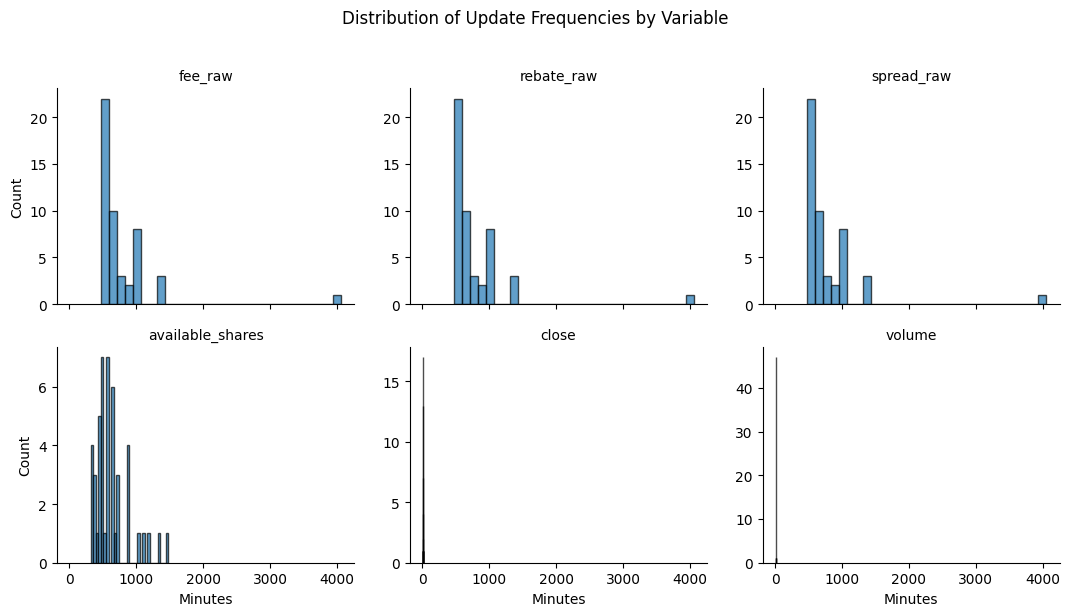

In [3]:
# examining true update frequency of variables
variables = 'fee_raw', 'rebate_raw','spread_raw', 'available_shares', 'close', 'volume'
filter_large_intervals = ['close', 'volume']
perticker_df = [group for _, group in df.groupby('ticker', sort=True)]

per_ticker_means = []

for tdf in perticker_df:
    row = {}
    for v in variables:
        change_times = tdf.loc[tdf[v].ne(tdf[v].shift()), 'asof_utc']
        intervals = change_times.diff().dt.total_seconds() / 60
        if v in filter_large_intervals:
                intervals = intervals[intervals < 30] #filter out market data intervals between trading days
        row[v] = intervals.mean()
    per_ticker_means.append(row) 

med_freq = pd.DataFrame(per_ticker_means).median()
print('Median update frequencies:')
print(med_freq)
df_long = pd.DataFrame(per_ticker_means).melt(
    value_vars=variables,
    var_name='Variable',
    value_name='Update Interval (minutes)'
)

g = sns.FacetGrid(df_long, col='Variable', col_wrap=3, sharey=False, height=3, aspect=1.2)
g.map(plt.hist, 'Update Interval (minutes)', bins=30, edgecolor='black', alpha=0.7)
g.set_titles("{col_name}")
g.set_axis_labels("Minutes", "Count")
plt.suptitle('Distribution of Update Frequencies by Variable', y=1.02)
plt.tight_layout()
plt.show()

Clearly there is a significant difference between the update frequencies of IB and YF data.


We can create an alternate dataset by removing all rows which don't include updates to any of the IB variables (these are the updates we care about, given the aim of the project. Even so, the market variables can be provided to arbitrary frequency anyway).
Lets do this, as well as setting up some variations for later.

## Regimes
Here we want to globally define regimes which will help us to discriminate between differently behaving securities. This will allow for later analysis to be more targeted.  
We will use a gaussian mixture model for clustering.

In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

def build_fee_stable_periods(df: pd.DataFrame, tol: float = 1e-6) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build fee-stable segments per ticker with true elapsed duration.
    Returns:
        df_sorted: original df with fee_event column
        stable_periods: one row per (ticker, fee_event) segment
    """
    df_sorted = df.sort_values(["ticker", "asof_utc"]).copy()

    # Fee change event with tolerance, and cumsum within each ticker
    fee_diff = df_sorted.groupby("ticker")["fee_raw"].diff()
    fee_change = fee_diff.isna() | fee_diff.abs().gt(tol) # first row of a diff is NaN
    df_sorted["fee_event"] = fee_change.groupby(df_sorted["ticker"]).cumsum().astype(int)

    g = df_sorted.groupby(["ticker", "fee_event"], sort=False)

    stable_periods = g.agg(
        fee_raw=("fee_raw", "first"),
        available_shares=("available_shares", "mean"),
        available_unlimited=("available_unlimited", "max") if "available_unlimited" in df_sorted.columns else ("fee_raw", lambda s: False),
        volume=("volume", "mean") if "volume" in df_sorted.columns else ("fee_raw", lambda s: np.nan),
        n_obs=("asof_utc", "size"),
        start=("asof_utc", "min"),
        end=("asof_utc", "max"),
    ).reset_index()

    stable_periods["duration_s"] = (stable_periods["end"] - stable_periods["start"]).dt.total_seconds().clip(lower=0)

    return df_sorted, stable_periods


def fit_gmm_regimes(
    stable_periods: pd.DataFrame,
    k_range=range(2, 3),          
    separate_unlimited: bool = True,
    clip_q: float = 0.995,
    random_state: int = 26,
):
    sp = stable_periods.copy()

    # optional: split unlimited into its own "structural supply" bucket
    unlim = (
        separate_unlimited
        and "available_unlimited" in sp.columns
        and sp["available_unlimited"].fillna(False).astype(bool)
    )

    base = sp.loc[~unlim].dropna(subset=["fee_raw", "available_shares"]).copy()

    # Robust transforms (signed log fee; log availability)
    fee = base["fee_raw"].astype(float)
    fee_cap = np.abs(fee).quantile(clip_q)
    fee_t = np.sign(fee) * np.log1p(np.abs(fee).clip(upper=fee_cap))

    avail = base["available_shares"].astype(float).clip(lower=0)
    avail_cap = avail.quantile(clip_q)
    avail_t = np.log1p(avail.clip(upper=avail_cap))

    X = np.c_[fee_t.to_numpy(), avail_t.to_numpy()]
    Xs = StandardScaler().fit_transform(X)

    # Fit models and pick best by BIC (plogN - 2l)
    models, bics = [], []
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            n_init=5,
            max_iter=500,
            reg_covar=1e-6,
            random_state=random_state,
        ).fit(Xs)
        models.append(gmm)
        bics.append(gmm.bic(Xs))

    best = models[int(np.argmin(bics))]
    labels = best.predict(Xs)

    # make labels interpretable: order by mean fee dimension (low → high)
    order = np.argsort(best.means_[:, 0])
    remap = {old: new for new, old in enumerate(order)}
    labels = pd.Series(labels, index=base.index).map(remap).astype(int)

    # assign back
    sp["regime"] = -1
    sp.loc[base.index, "regime"] = labels.values

    if separate_unlimited and isinstance(unlim, pd.Series) and unlim.any():
        sp.loc[unlim, "regime"] = sp.loc[~unlim, "regime"].max() + 1

    selection = pd.DataFrame({"k": list(k_range), "bic": bics}).sort_values("k").reset_index(drop=True)
    return sp, selection



# build stable periods
df_sorted, stable_periods = build_fee_stable_periods(df, tol=1e-6)

# fit GMM regimes
stable_periods_labeled, selection = fit_gmm_regimes(
    stable_periods,
    random_state=26,
    k_range=range(2,4),
    separate_unlimited=True,
    clip_q=0.99,
)

print("GMM model selection (lower BIC is better):")
print(selection)

# merge regime back onto original df rows 
df_with_regime = df_sorted.merge(
    stable_periods_labeled[["ticker", "fee_event", "regime"]],
    on=["ticker", "fee_event"],
    how="left",
)
df_with_regime["abs_ret_trailing"] = df_with_regime.sort_values(["ticker","asof_utc"]).groupby("ticker")["close"].transform(lambda x: np.log(x / x.shift(1)).abs())
df_with_regime["log_volume"] = np.log1p(df_with_regime["volume"])
df_with_regime = df_with_regime.dropna(subset=["abs_ret_trailing", "log_volume", "available_shares"])


summary = stable_periods_labeled.groupby("regime").agg(
    n_periods=("regime", "size"),
    n_tickers=("ticker", "nunique"),
    avg_fee=("fee_raw", "mean"),
    med_fee=("fee_raw", "median"),
    avg_avail=("available_shares", "mean"),
    med_avail=("available_shares", "median"),
    med_duration_s=("duration_s", "median"),
).sort_index()

print("\nRegime summary:")
print(summary)


GMM model selection (lower BIC is better):
   k          bic
0  2  1033.317663
1  3   999.880739

Regime summary:
        n_periods  n_tickers     avg_fee   med_fee     avg_avail  \
regime                                                             
0             209         29    0.475062   0.47350  3.055134e+06   
1              50          9    1.717012   1.34325  2.912566e+06   
2              78         13  103.185695  27.90415  6.535391e+05   
3              19          6    0.816921   0.55230  9.789186e+06   

           med_avail  med_duration_s  
regime                                
0       2.377778e+06          7455.0  
1       2.100000e+06          7455.0  
2       4.966667e+05          9329.5  
3       1.000000e+07          9328.0  


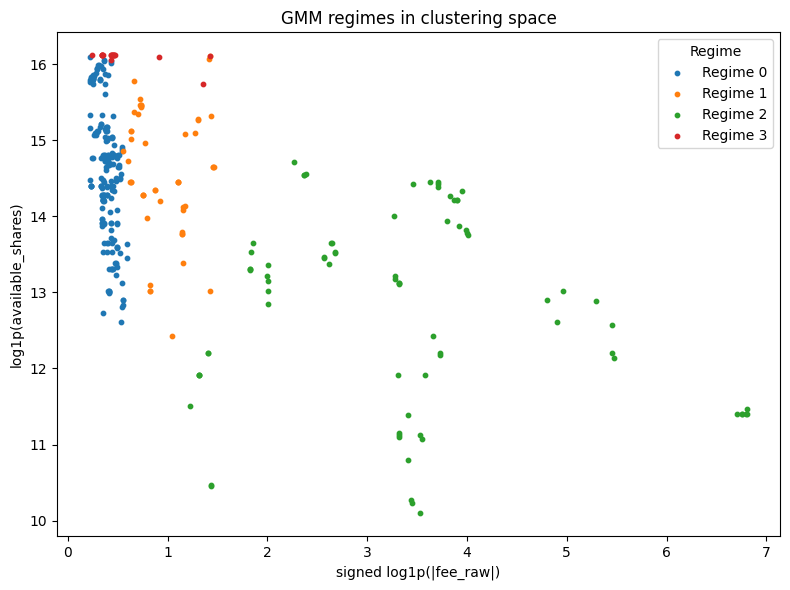

In [5]:
sp = stable_periods_labeled.copy()

# same transforms used for clustering (no clipping on fee)
fee = sp["fee_raw"].astype(float)
log_fee = np.sign(fee) * np.log1p(np.abs(fee))

avail = sp["available_shares"].astype(float).clip(lower=0)
log_avail = np.log1p(avail)

# plot
plt.figure(figsize=(8, 6))

for regime in sorted(sp["regime"].unique()):
    mask = sp["regime"] == regime
    plt.scatter(
        log_fee[mask],
        log_avail[mask],
        s=10,
        label=f"Regime {regime}"
    )

plt.xlabel("signed log1p(|fee_raw|)")
plt.ylabel("log1p(available_shares)")
plt.title("GMM regimes in clustering space")
plt.legend(title="Regime")
plt.tight_layout()
plt.show()

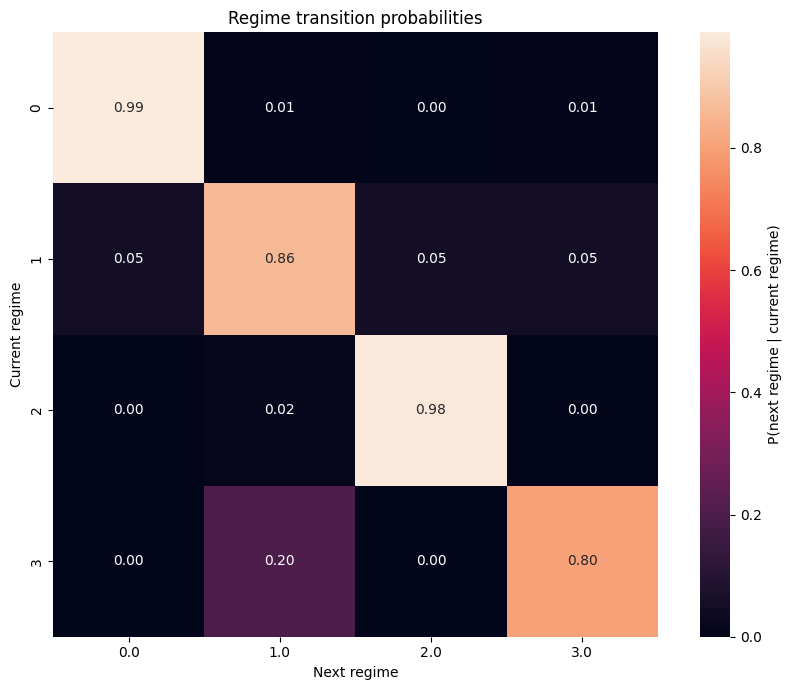

In [6]:
#transition matrix

sp = stable_periods_labeled.sort_values(["ticker", "fee_event"]).copy()
# next regime within ticker (one-step ahead)
sp["next_regime"] = sp.groupby("ticker")["regime"].shift(-1)

# count transitions: from current regime (rows) -> next regime (cols)
tm = (
    sp.dropna(subset=["next_regime"])
      .groupby(["regime", "next_regime"])
      .size()
      .unstack(fill_value=0)
)

# row-normalized probabilities P(next=j | current=i)
row_sums = tm.sum(axis=1)
tm_prob = tm.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    tm_prob,
    annot=True,        # show probabilities in cells
    fmt=".2f",
    square=True,
    cbar_kws={"label": "P(next regime | current regime)"}
)

ax.set_xlabel("Next regime")
ax.set_ylabel("Current regime")
ax.set_title("Regime transition probabilities")

plt.tight_layout()
plt.show()


Interpretation:

- Regime 0: 'Normal', low fee, relatively high availability  
- Regime 1: 'Elevated', higher fee than baseline, relatively high availability  
- Regime 2: 'Scarce', extremely high fee, low availability  
- Regime 3: 'unlimited', low-medium fee, extremely high availability

Tickers tend to stay in their own regimes (at least in this 100h period), aside from some movement from 3 --> 1. This should correspond with some decrease in availability, although it's hard to say whether this might be a result of sub-optimal clustering (regimes too similar) or actual reductions in the number of available shares.

The regime itself can be interpreted as a categorical feature, or we can similarly use time spent in a certain regime or recent transitions.
For now lets, make subsets of the dataset within these regimes.

In [7]:
#constructing dataset variants with regimes
df = df_with_regime.sort_values(["ticker", "asof_utc"]).copy()

# df_changes (event-time on IB vars), within ticker
IB_variables = ["fee_raw", "available_shares"]

mask = df[IB_variables].ne(df.groupby("ticker")[IB_variables].shift()).any(axis=1)
df_changes = df.loc[mask].copy()
df_changes = df_changes.groupby("ticker").filter(lambda x: len(x) >= 10).copy()


# df_first_diff (first differences; log close + log volume)
fd_cols = ["ticker", "asof_utc", "regime", "fee_raw", "available_shares", "close", "volume"]
df_fd_temp = df[fd_cols].copy()

# log-transform close/volume; handle inf from log(0)
df_fd_temp[["close", "volume"]] = np.log(df_fd_temp[["close", "volume"]]).replace([np.inf, -np.inf], np.nan)

# diff numeric cols within ticker
num_cols_fd = ["fee_raw", "available_shares", "close", "volume"]
df_first_diff = df_fd_temp.groupby("ticker")[num_cols_fd].diff()

# reattach keys/labels
df_first_diff["ticker"] = df_fd_temp["ticker"].values
df_first_diff["asof_utc"] = df_fd_temp["asof_utc"].values
df_first_diff["regime"] = df_fd_temp["regime"].values

df_first_diff = df_first_diff.dropna().copy()


# df_changes_first_diff (first differences, but only on change-rows)
ch_cols = ["ticker", "asof_utc", "regime", "fee_raw", "spread_raw", "available_shares", "close", "volume"]
df_ch_temp = df_changes[ch_cols].copy()

df_ch_temp[["close", "volume"]] = np.log(df_ch_temp[["close", "volume"]]).replace([np.inf, -np.inf], np.nan)

num_cols_ch = ["fee_raw", "spread_raw", "available_shares", "close", "volume"]
df_changes_first_diff = df_ch_temp.groupby("ticker")[num_cols_ch].diff()

df_changes_first_diff["ticker"] = df_ch_temp["ticker"].values
df_changes_first_diff["asof_utc"] = df_ch_temp["asof_utc"].values
df_changes_first_diff["regime"] = df_ch_temp["regime"].values

df_changes_first_diff = (
    df_changes_first_diff
    .dropna(subset=["fee_raw", "close"], how="all")
    .dropna(subset=["close"])
    .copy()
)


# df_pooled (time-averaged)
df_pooled = df.groupby(["ticker", "regime"], sort=True).mean(numeric_only=True)
df_pooled = df_pooled[["fee_raw", "available_shares", "close", "volume"]].copy()



#split dataset variants into regimes

for r, sub in df_changes.groupby("regime"):
    globals()[f"df_changes_{int(r)}"] = sub.copy()

for r, sub in df_first_diff.groupby("regime"):
    globals()[f"df_first_diff_{int(r)}"] = sub.copy()

for r, sub in df_changes_first_diff.groupby("regime"):
    globals()[f"df_changes_first_diff_{int(r)}"] = sub.copy()

# df_pooled has a MultiIndex (ticker, regime). easiest: reset index first
df_pooled_reset = df_pooled.reset_index()
for r, sub in df_pooled_reset.groupby("regime"):
    globals()[f"df_pooled_{int(r)}"] = sub.copy()

Note that we haven't included the rebate rate in these constructions, as every change in fee is accompanied with an equal (in magnitude) and opposite change in rebate. In the context of price prediction we clearly don't need to keep both.

## Typical Changes

### Change Distribution
What are typical changes to fees and availabile shares in a single timestep?

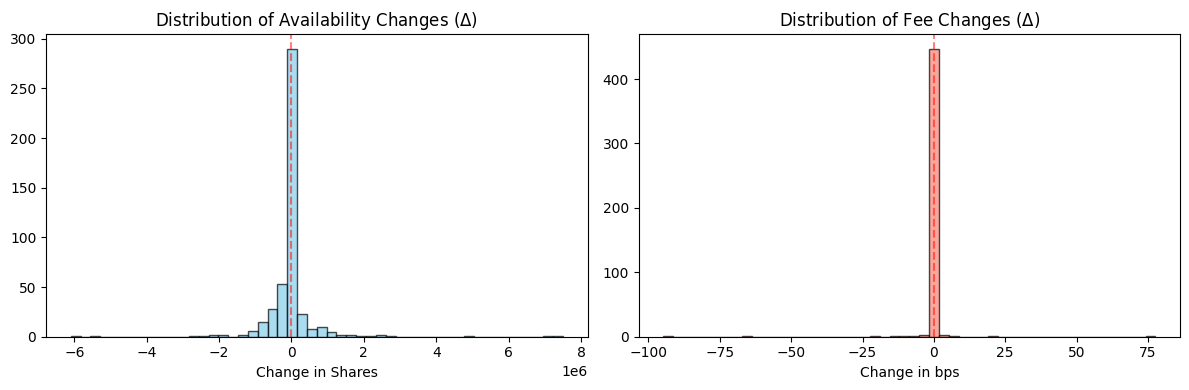

In [8]:
#fee and availability deltas
delta_fee = df_changes.groupby('ticker')['fee_raw'].diff().dropna()
delta_avail = df_changes.groupby('ticker')['available_shares'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Availability Changes
ax1.hist(delta_avail, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of Availability Changes ($\Delta$)')
ax1.set_xlabel('Change in Shares')
ax1.axvline(0, color='red', linestyle='--', alpha=0.5) 

# Fee Changes
ax2.hist(delta_fee, bins=50, color='salmon', edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Fee Changes ($\Delta$)')
ax2.set_xlabel('Change in bps')
ax2.axvline(0, color='red', linestyle='--', alpha=0.5) 

plt.tight_layout()
plt.show()

Both are roughly symmetric around 0, as expected. They are also heavily spiked near 0, despite being calculated from the 'changes' dataset, showing that fee and availability adjustments are small. With this being largely expected we can continue the rest of the analysis. Note there are also some very large changes in fees, which perhaps correspond to transitions from regime 1 to regime 2.

### PCA of Fee Changes
Analysing cross-correlations between fee movements of different securities.

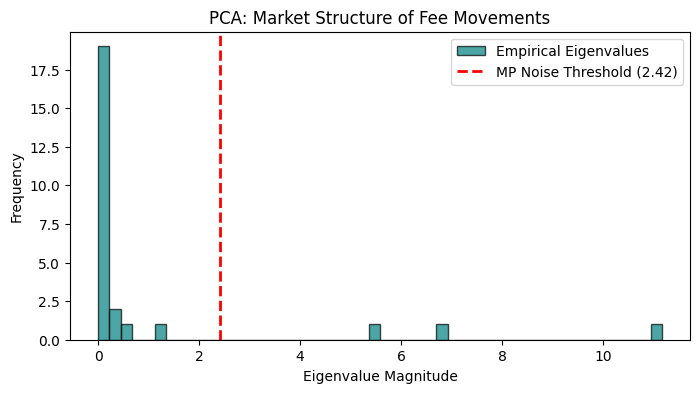

In [23]:
from sklearn.preprocessing import StandardScaler

df_first_diff['timestep'] = df_first_diff.groupby('ticker').cumcount()
#  pivot using the new 'timestep' as the index
wide_fee = df_first_diff.pivot(index='timestep', columns='ticker', values='fee_raw')
wide_fee = wide_fee.dropna(axis=1, how='any')
wide_fee = wide_fee.loc[:, (wide_fee != 0).any(axis=0)]

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wide_fee) 


corrmatrix = np.corrcoef(X_scaled, rowvar=False)

# eigendecomposition
evals, evecs = np.linalg.eigh(corrmatrix)
evals = evals[::-1] # Sort descending (highest variance first)
evecs = evecs[:, ::-1]

# Marchenko-Pastur threshold
# T = number of observations (rows), N = number of variables (tickers)
T, N = X_scaled.shape
Q = T / N
noisethresh = (1 + np.sqrt(1/Q))**2 

plt.figure(figsize=(8, 4))
plt.hist(evals, bins=50, alpha=0.7, color='teal', edgecolor='black', label='Empirical Eigenvalues')
plt.axvline(noisethresh, color='red', linestyle='--', linewidth=2, label=f'MP Noise Threshold ({noisethresh:.2f})')
plt.title('PCA: Market Structure of Fee Movements')
plt.xlabel('Eigenvalue Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.show()

signal_eigenvalues = evals[evals > noisethresh]

Lets now examine the largest eigenmode.

Proportion of accounted variance from largest eigenvalue: 0.43


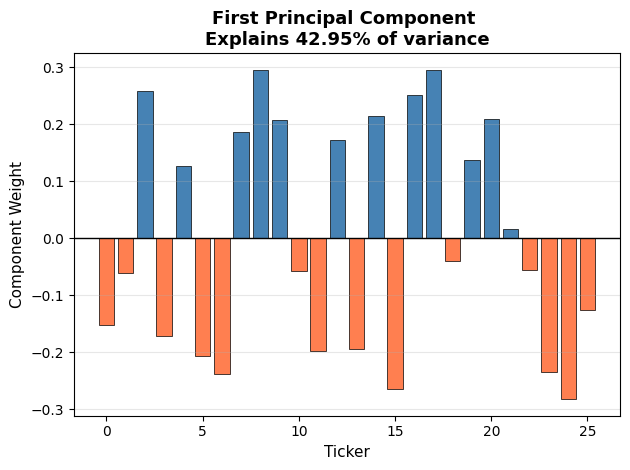

In [10]:
print(f'Proportion of accounted variance from largest eigenvalue: {np.round(evals[0]/np.sum(evals), 3)}')
pc1 = evecs[:, 0]
    

colors = ['steelblue' if x > 0 else 'coral' for x in pc1]
plt.bar(range(len(pc1)), pc1, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Ticker', fontsize=11)
plt.ylabel('Component Weight', fontsize=11)
plt.title(f'First Principal Component \nExplains {evals[0]/np.sum(evals)*100:.2f}% of variance', 
                fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Unfortunately, the largest principal component has picked up the simultaneous updating of fees, rather than anything meaningful.
This is also supported by looking at a timeseries of proportion of updates:

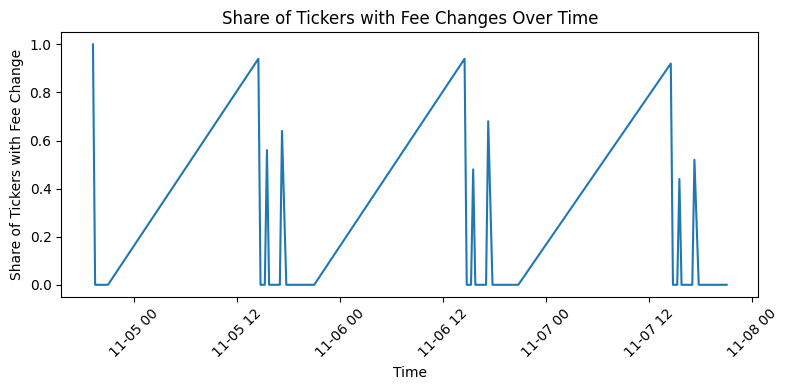

In [11]:

# round timestamps to 15min intervals
df['time_15m'] = df['asof_utc'].dt.round('15min')

# group by ticker and time, check if fee changed from previous observation
grouped = df.groupby('ticker').apply(
    lambda x: x.assign(fee_changed=(x['fee_bps'].diff() != 0).fillna(False))
).reset_index(drop=True)

# calculate share of tickers with fee change at each timestamp
ts = grouped.groupby('time_15m').agg(
    tickers_changed=('fee_changed', 'sum'),
    total_tickers=('ticker', 'nunique')
)
ts['share'] = ts['tickers_changed'] / ts['total_tickers']

plt.figure(figsize=(8, 4))
plt.plot(ts.index, ts['share'])
plt.xlabel('Time')
plt.ylabel('Share of Tickers with Fee Change')
plt.title('Share of Tickers with Fee Changes Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can conclude that many stocks exhibit fee changes within the same update window. This analysis could still be useful if performed on a larger set of tickers over a larger amount of time, however it isn't meaningful for this dataset.

However, given this new bit of information, we can deduce that (at least within this dataset) fees are updated systematically each day rather than independent intraday fee calculation.
This makes intraday strategies based on fee change signals infeasible.

Additionally, if the vast majority of fee changes happen at a specific time, then an 'out-of-cycle' fee change may indicate something significant. This could be useful to look into further (although unfortunately this dataset only contains dense update rows) by looking into the behaviour of the security around this anomalous fee change.

### Autocorrelation of Fee Changes
Here our goal is to determine whether fee changes tend to persist or revert to the mean within our different regimes.

In [12]:
#ACF
VALUE_COLS = ["fee_raw", "available_shares"]

def lag1_autocorr_summary(df_in: pd.DataFrame, value_col: str) -> dict:
    d = df_in.sort_values(["ticker", "asof_utc"])

    # Lag-1 autocorr per ticker (require >= 3 points)
    acf_by_ticker = (
        d.groupby("ticker")[value_col]
         .apply(lambda s: s.dropna().autocorr(lag=1) if s.dropna().shape[0] >= 3 else np.nan)
         .dropna()
    )

    return {
        "n_tickers": int(acf_by_ticker.shape[0]),
        "mean_acf1": float(acf_by_ticker.mean()) if len(acf_by_ticker) else np.nan,
        "median_acf1": float(acf_by_ticker.median()) if len(acf_by_ticker) else np.nan,
        "cv_acf1": abs(float(acf_by_ticker.std(ddof=1))/float(acf_by_ticker.mean())) if len(acf_by_ticker) > 1 else np.nan, #coeff of variation
    }

results = []
for col in VALUE_COLS:
    for r, sub in df_changes_first_diff.groupby("regime"):
        out = lag1_autocorr_summary(sub, col)
        out["regime"] = int(r)
        out["var"] = col
        results.append(out)

acf_regime_summary = (
    pd.DataFrame(results)
      .sort_values(["var", "regime"])
      .reset_index(drop=True)
)

print(acf_regime_summary.to_string(index=False))

 n_tickers  mean_acf1  median_acf1  cv_acf1  regime              var
        23  -0.242566    -0.220448 0.934097       0 available_shares
         6  -0.145234    -0.119358 1.777105       1 available_shares
         7  -0.254773    -0.151523 0.961060       2 available_shares
         2  -0.079964    -0.079964 5.846569       3 available_shares
        23  -0.075502    -0.039243 2.186619       0          fee_raw
         6  -0.047661    -0.033698 3.959227       1          fee_raw
         7  -0.031855    -0.002458 2.346942       2          fee_raw
         1  -0.335439    -0.335439      NaN       3          fee_raw


Note that we are in event-time (i.e. we are comparing consecutive changes rather than timesteps), and also that some rows have a tiny N (see regime 3).
- Lag-1 autocorrelation of availability changes is consistently negative in regimes 0–2, indicating reversals between consecutive updates. This is consistent with availability behaving like a mean-reverting process at update level, though it could also reflect update mechanics or simply noise.
- Lag-1 autocorrelation of fee changes is small, with a large coefficient of variation across all regimes. 

Because observed changes in availability seem to be mean-reverting, constructing features that depend on sustained, one-sided trends is unlikely to yield reliable signals. A more effective approach focuses on characterizing the reversal dynamics themselves. This suggests designing metrics that capture the pattern of these alternations, or that identify and measure the impact of significant downward jumps.

Similarly, fee changes exhibit little predictable structure in their sequence, showing weak and unstable autocorrelation. This rules out features that assume simple persistence or reversion in fee movements. Instead, the informational value of fees is better captured through their absolute level (e.g their ranking or regime) and through discrete events like abrupt increases. These will likely be most informative when considered in combination with availability conditions.

### Mutual Information
Here we examine the mutual information between the set of IB and YF variables, within each regime.

In [13]:
#lagged_mi
from sklearn.feature_selection import mutual_info_regression

def mi_lag1_per_regime(df, pairs, min_tickers=5, min_len_per_ticker=10, min_rows_after_dropna=6,
                      cv_ddof=1, eps=1e-12):
    rows = []
    for r, sub in df.groupby("regime"):
        n_tickers_total = sub["ticker"].nunique()
        if n_tickers_total < min_tickers:
            continue

        for a, b in pairs:
            mi_scores = []
            n_used = 0

            for _, g in sub.groupby("ticker"):
                if len(g) < min_len_per_ticker:
                    continue

                data = pd.DataFrame({
                    "x": g[a],
                    "y": g[b].shift(-1)   # lag=1 in event-time
                }).dropna()

                if len(data) < min_rows_after_dropna:
                    continue

                mi = mutual_info_regression(
                    data[["x"]],
                    data["y"],
                    discrete_features=False
                )[0]

                mi_scores.append(mi)
                n_used += 1

            if mi_scores:
                mi_scores = np.asarray(mi_scores, dtype=float)
                mean_mi = float(np.mean(mi_scores))
                std_mi = float(np.std(mi_scores, ddof=cv_ddof)) if len(mi_scores) > 1 else 0.0
                cv = (std_mi / (mean_mi + eps)) if mean_mi > 0 else np.nan

                rows.append({
                    "Regime": int(r),
                    "N_tickers_total": int(n_tickers_total),
                    "N_tickers_used": int(n_used),
                    "Pair": f"{a} -> next {b}",
                    "MI_lag1_mean": mean_mi,
                    "MI_lag1_std": std_mi,
                    "MI_lag1_cv": float(cv) if np.isfinite(cv) else np.nan,
                })

    return pd.DataFrame(rows)

target_pairs = [
    ('fee_raw', 'close'), 
    ('fee_raw', 'volume'),
    ('available_shares', 'close'),
    ('available_shares', 'volume'),
    ('available_shares', 'fee_raw')
]

mi_df = mi_lag1_per_regime(df_changes_first_diff, target_pairs, min_tickers=5)

mi_mean_pivot = mi_df.pivot(index="Pair", columns="Regime", values="MI_lag1_mean").round(4)
mi_cv_pivot   = mi_df.pivot(index="Pair", columns="Regime", values="MI_lag1_cv").round(4)

print("Mean MI (lag1):")
print(mi_mean_pivot)
print("\nCV of MI across tickers (lag1):")
print(mi_cv_pivot)


Mean MI (lag1):
Regime                                 0       1       2
Pair                                                    
available_shares -> next close    0.0258  0.0000  0.0654
available_shares -> next fee_raw  0.1137  0.1588  0.1424
available_shares -> next volume   0.1885  0.1460  0.0603
fee_raw -> next close             0.0375  0.0085  0.0748
fee_raw -> next volume            0.0779  0.1273  0.0527

CV of MI across tickers (lag1):
Regime                                 0       1       2
Pair                                                    
available_shares -> next close    2.4974     NaN  0.8559
available_shares -> next fee_raw  0.8018  0.2308  0.6721
available_shares -> next volume   0.8450  0.8827  1.0200
fee_raw -> next close             1.3492  1.3684  0.8363
fee_raw -> next volume            1.1377  0.3103  0.6756


Note that we are not necessarily expecting a high MI score between IB and close price, given that the IB variables signify borrowing contraints/scarcity. 

In regimes 0 and 1(standard and elevated fees), we notice a potential relationship between availability and the future volume.

Lets examine these further with variable correlations.

### Variable Correlations

In [14]:
#lagged correlations
def mean_lag_corr_per_ticker(df, a, b, lag=1, min_rows=6):
    """
    For each ticker: corr(a_t, b_{t+lag}), then average across tickers.
    """
    def corr_one(x):
        x = x[[a, b]].dropna()
        if len(x) < (min_rows + lag):
            return np.nan
        return x[a].corr(x[b].shift(-lag))

    corrs = df.groupby("ticker").apply(corr_one).dropna()
    return corrs.mean(), corrs.median(), corrs.shape[0]


def lag1_correlations_by_regime(df, pairs, min_tickers=5, lag=1):
    rows = []
    for r, sub in df.groupby("regime"):
        n_tickers_total = sub["ticker"].nunique()
        if n_tickers_total < min_tickers:
            print(f"Skipping regime {int(r)} (only {n_tickers_total} tickers)")
            continue

        for a, b in pairs:
            mean_c, med_c, n_used = mean_lag_corr_per_ticker(sub, a, b, lag=lag)
            rows.append({
                "Regime": int(r),
                "N_tickers_total": int(n_tickers_total),
                "N_tickers_used": int(n_used),
                "Pair": f"{a} -> next {b}",
                "Corr_lag1_mean": mean_c,
                "Corr_lag1_median": med_c,
            })

    out = pd.DataFrame(rows)
    return out


# run
target_pairs = [('fee_raw', 'close'), ('fee_raw', 'volume'),('available_shares', 'close'),('available_shares', 'volume'),('available_shares', 'fee_raw')]
corr_df = lag1_correlations_by_regime(df_first_diff, target_pairs, min_tickers=5, lag=1)

# readable output: pivot of mean correlations
corr_pivot = corr_df.pivot(index="Pair", columns="Regime", values="Corr_lag1_mean").round(2)
print("Mean lag-1 correlation (per-ticker averaged):")
print(corr_pivot)

# optional: also show how many tickers actually contributed per cell
used_pivot = corr_df.pivot(index="Pair", columns="Regime", values="N_tickers_used")
print("\n# tickers contributing to each estimate:")
print(used_pivot)


Mean lag-1 correlation (per-ticker averaged):
Regime                               0     1     2     3
Pair                                                    
available_shares -> next close    0.05  0.08  0.07  0.19
available_shares -> next fee_raw -0.04  0.06  0.05 -0.07
available_shares -> next volume  -0.26 -0.19 -0.08 -0.13
fee_raw -> next close            -0.01  0.05  0.02 -0.01
fee_raw -> next volume            0.01 -0.05  0.04  0.04

# tickers contributing to each estimate:
Regime                             0  1   2  3
Pair                                          
available_shares -> next close    29  8  12  3
available_shares -> next fee_raw  29  7  12  1
available_shares -> next volume   29  8  12  3
fee_raw -> next close             29  7  13  4
fee_raw -> next volume            29  7  13  4


Across regimes 0 and 1 (normal and elevated fee - where most tickers lie), availability changes are negatively correlated with the next change in trading volume, which confirms the possible relationship indicated by the above MI score.
Also as expected, the direct linear predictability of price returns is weak. This means that later feature proposals should perhaps focus on regime transitions, scarcity or volatility proxies rather than direct predictions from fee/availability behaviour.

### Threshold model
Exploring whether fee updates could be a result of some hidden variable crossing a threshold, which triggers a fee update at the next global update window, using logistic regression.

In [15]:
#logistic regression on fee changes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df_thresh = df_with_regime.sort_values(["ticker", "asof_utc"]).copy()

# target: 1 if fee changed vs previous row for that ticker
df_thresh["fee_updated"] = df_thresh.groupby("ticker")["fee_raw"].diff().ne(0).astype(int)

# features: trailing abs log return and log volume, plus availability
df_thresh["abs_ret_trailing"] = df_thresh.groupby("ticker")["close"].transform(
    lambda x: np.log(x / x.shift(1)).abs()
)
df_thresh["log_volume"] = np.log1p(df_thresh["volume"])

features = ["abs_ret_trailing", "log_volume", "available_shares"]
df_thresh = df_thresh.dropna(subset=features + ["fee_updated", "regime"])

rows = []
min_pos = 20
min_neg = 20

for r, sub in df_thresh.groupby("regime"):
    y = sub["fee_updated"].values
    n_pos = int(y.sum())
    n_neg = int((1 - y).sum())
    if n_pos < min_pos or n_neg < min_neg:
        print(f"Skipping regime {int(r)} (pos={n_pos}, neg={n_neg})")
        continue

    X = sub[features].values
    Xs = StandardScaler().fit_transform(X)

    model = LogisticRegression(class_weight="balanced", max_iter=2000)
    model.fit(Xs, y)

    coefs = model.coef_[0]
    for f, c in zip(features, coefs):
        rows.append({
            "Regime": int(r),
            "N_rows": len(sub),
            "Pos_rate": n_pos / len(sub),
            "Feature": f,
            "Coef": c,
            "OddsRatio": float(np.exp(c)),
        })

coef_df = pd.DataFrame(rows)

coef_pivot = coef_df.pivot(index="Feature", columns="Regime", values="Coef").round(4)
odds_pivot = coef_df.pivot(index="Feature", columns="Regime", values="OddsRatio").round(3)

print("Pos_rate and sample size by regime:")
print(coef_df.drop_duplicates("Regime")[["Regime", "N_rows", "Pos_rate"]].sort_values("Regime"))

print("\nCoefficients (standardized inputs):")
print(coef_pivot)

print("\nOdds ratios (exp(coef)):")
print(odds_pivot)


Skipping regime 3 (pos=15, neg=281)
Pos_rate and sample size by regime:
   Regime  N_rows  Pos_rate
0       0    2344  0.077645
3       1     534  0.078652
6       2    1026  0.065302

Coefficients (standardized inputs):
Regime                 0       1       2
Feature                                 
abs_ret_trailing  0.5769  0.3568  0.6985
available_shares -0.0860 -0.1602 -0.2161
log_volume        0.3592  0.4931  0.5857

Odds ratios (exp(coef)):
Regime                0      1      2
Feature                              
abs_ret_trailing  1.781  1.429  2.011
available_shares  0.918  0.852  0.806
log_volume        1.432  1.637  1.796


The odds ratio is the fraction by which the ratio of fee change/no change increases, given a 1SD increase in a given variable (in a given regime).

We see that the strongest predictor of fee changes is the magnitude of the recent return (volatility), especially in regime 2 (stressed/scarce securities with high fees and low availability). 

There are similarly high odds ratios for the log_volume, although this could be driven by the same underlying factor as above.
Lastly, odds ratios <1 (negative coeffs) are seen across the board for the number of available shares. This makes sense: when borrow supplies are high, fees are less likely to be revised and when supply is scarce, fee updates are more likely.

We also see that the magnitude of coefficients is largest in all variables in regime 2. This is because more stressed/scarce securities are likely to have more fee changes overall, and also to respond most dramatically to changes in market variables.

If a likely/immenent fee change was used as a signal, then this model could be used to output the probability that the next step will be a fee change (let each timestep be, say, 24h), which could be used as a feature.

# Feature Proposals

Now we'll use everything above to justify some plausible features to use in a ML model used for pricing dynamics prediction. We won't strive to directly predict future returns, but rather suggest some auxilliary features which could improve an existing model by better capturing future volatility or hidden states. *** 

### Regime and regime transitions



In [16]:
df_with_regime = df_with_regime.sort_values(["ticker", "asof_utc"]).copy()
g = df_with_regime.groupby("ticker")

**Borrow Regime** - lets simply start with the regime as determined by clustering in log_fee-log_availability space.

In [17]:
df_with_regime["regime"]

1       1
2       1
3       1
4       1
5       1
       ..
4295    2
4296    2
4297    2
4298    2
4299    2
Name: regime, Length: 4250, dtype: int64

The borrow market behaves nonlinearly: stocks transition between “normal,” “tight,” and “stress” states due to inventory constraints and shorting interest, so conditioning predictions on a regime helps models capture asymmetric dynamics (e.g., returns/volatility responses differ when borrow is scarce).

For example, a regime label is a way to let the model treat the same fee level differently depending on whether it’s occurring in a broadly liquid context or inside a constrained state. If this feature adds value, it should hopefully show that downstream predictions (especially volatility or tail-risk proxies) are more separable when conditioned on regime than when using raw fee/availability alone.

**Entered stress regime** - Flags when a security enters the stressed regime, which could signify different characteristic from previous timesteps.

In [18]:
stress_regime = 2
df_with_regime["entered_stress_regime"] = ((df_with_regime["regime"] == stress_regime) & (g["regime"].shift(1) != stress_regime)).astype(int)

Transitions into the stressed regime, captures events which are more likely to matter than steady-state periods. The reason to prefer a transition feature over a regime label alone is that it captures 'news' (a discrete shift in borrow state) rather than 'background conditions.'

### Availability dynamics
As informed by the negative lag-1 ACF, shock and reversal-aware features are more suitable than trend features.

**Scarcity shock** - Flags availability changes which are in the top 1 percent of negative changes (first percentile) for each regime.

In [19]:
df_with_regime["d_avail"] = g["available_shares"].diff()
q_avail = df_with_regime.groupby("regime")["d_avail"].transform(lambda s: s.quantile(0.01))
df_with_regime["avail_shock_down"] = (df_with_regime["d_avail"] < q_avail).astype(int)

Unusually large drops in availability (relative to the regime) may represent sudden scarcity shocks rather than routine noise.
A sudden drop in availability is consistent with locates being consumed, lenders pulling inventory, recalls, or a reclassification of lendable shares, any of which can tighten short-sale constraints quickly. That tightening could transmit to prices indirectly.
Should also also handle available_unlimited=True by setting shock to 0.

### Fee dynamics
Despite not finding out as much about the behaviour of fees and relation to other variables, there are some metrics which are likely to be useful.

**Fee Spike** - Flag rare fee spikes as meaningful events.

In [20]:
df_with_regime["d_fee"] = g["fee_raw"].diff()
q_fee = df_with_regime.groupby("regime")["d_fee"].transform(lambda s: s.quantile(0.99))
df_with_regime["fee_spike_flag"] = (df_with_regime["d_fee"] > q_fee).astype(int)

Rare stress events likely to be more informative than typical updates. When borrow fees jump quickly, it can reflect a discrete shift in the supply–demand balance for lendable shares, such as inventory drying up, lenders recalling shares, or a sudden surge in borrow demand.

**Fee Update Likelihood** - Likelihood of a fee updating at given timestep.

In [21]:
X_placeholder = np.zeros((len(df_with_regime), model.n_features_in_))
df_with_regime["p_fee_update_next"] = model.predict_proba(X_placeholder)[:, 1]


This converts the fitted logistic model into a single interpretable feature: the estimated probability that IB will update the borrow fee at that observation given current market activity (abs return, volume) and supply (availability). The rationale is that markets tend to be more volatile when constraints and financing conditions are being actively repriced, so a high update likelihood can be a forward-looking proxy for this.

**Out-of-cycle update** - Does an update does occur at the usual batch update time (which happens to be around midday)?

In [22]:
df_with_regime = df_with_regime.sort_values(["ticker", "asof_utc"]).copy()

df_with_regime["fee_updated"] = df_with_regime.groupby("ticker")["fee_raw"].diff().ne(0).astype(int)
BIN = "15min"     
TOP_BINS = 2      
df_with_regime["tod_bin"] = df_with_regime["asof_utc"].dt.floor(BIN).dt.strftime("%H:%M")
tod_counts = df_with_regime.groupby("tod_bin")["fee_updated"].sum().sort_values(ascending=False)
top_tod_bins = tod_counts.head(TOP_BINS).index  # these are the "in-cycle" bins
df_with_regime["in_update_window"] = df_with_regime["tod_bin"].isin(top_tod_bins).astype(int)
df_with_regime["out_of_cycle_update"] = ((df_with_regime["fee_updated"] == 1) & (df_with_regime["in_update_window"] == 0)).astype(int)

Flags fee updates occurring outside the usual daily update window, treating them as rarer and potentially more informative deviations from scheduled refresh mechanics.
The intuition is that routine updates may dilute the signal because they’re partly scheduled recalibration, while out-of-cycle updates are more likely triggered by a real change in supply/demand conditions—recalls, sudden locate demand, corporate actions, or abrupt inventory movements, all which may be useful for a model to be able to distinguish from regular fee change noise.